# 🎓 Phân tích khám phá dữ liệu (EDA) - Student Depression Dataset

## 0. Cài đặt thư viện

In [76]:
# Bỏ comment nếu chưa cài
# !pip install notebook ipykernel pandas numpy scikit-learn matplotlib seaborn xgboost

## 1. Import thư viện & Cấu hình

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing    import LabelEncoder
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Hằng số ──────────────────────────────────────────────────────────────────
DATA_PATH    = './data/Student_Depression_Dataset.csv'
TARGET_COL   = 'Depression'
COLORS       = {'green': '#4CAF50', 'red': '#F44336',
                'blue': '#2196F3', 'orange': '#FF9800', 'purple': '#9C27B0'}

print("✅ Import hoàn tất!")

✅ Import hoàn tất!


## 2. Mô tả tập dữ liệu

### 2.1 Tải dữ liệu & Thông tin tổng quan

In [78]:
df = pd.read_csv(DATA_PATH)

print(f"📊 Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột")
df.head()

📊 Kích thước: 27,901 dòng × 18 cột


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


### 2.2 Kiểu dữ liệu & Cấu trúc

In [79]:
info_df = pd.DataFrame({
    'Cột': df.columns,
    'Kiểu dữ liệu': df.dtypes.values,
    'Số giá trị không null': df.notnull().sum().values,
    'Số giá trị unique': df.nunique().values,
    'Ví dụ': [str(df[c].dropna().iloc[0]) if len(df[c].dropna()) > 0 else 'N/A'
              for c in df.columns]
})
print(info_df.to_string(index=False))

                                  Cột Kiểu dữ liệu  Số giá trị không null  Số giá trị unique         Ví dụ
                                   id        int64                  27901              27901             2
                               Gender       object                  27901                  2          Male
                                  Age      float64                  27901                 34          33.0
                                 City       object                  27901                 52 Visakhapatnam
                           Profession       object                  27901                 14       Student
                    Academic Pressure      float64                  27901                  6           5.0
                        Work Pressure      float64                  27901                  3           0.0
                                 CGPA      float64                  27901                332          8.97
                   Study Satisfaction

## 3. Tiền xử lý dữ liệu
### 3.1 Missing values

In [80]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Số thiếu': missing, 'Tỷ lệ (%)': missing_pct})
miss_df = miss_df[miss_df['Số thiếu'] > 0]

if len(miss_df) == 0:
    print("✅ Không có missing values!")
else:
    print(f"⚠️  Phát hiện {miss_df['Số thiếu'].sum()} giá trị thiếu:")
    print(miss_df.to_string())

⚠️  Phát hiện 3 giá trị thiếu:
                  Số thiếu  Tỷ lệ (%)
Financial Stress         3       0.01


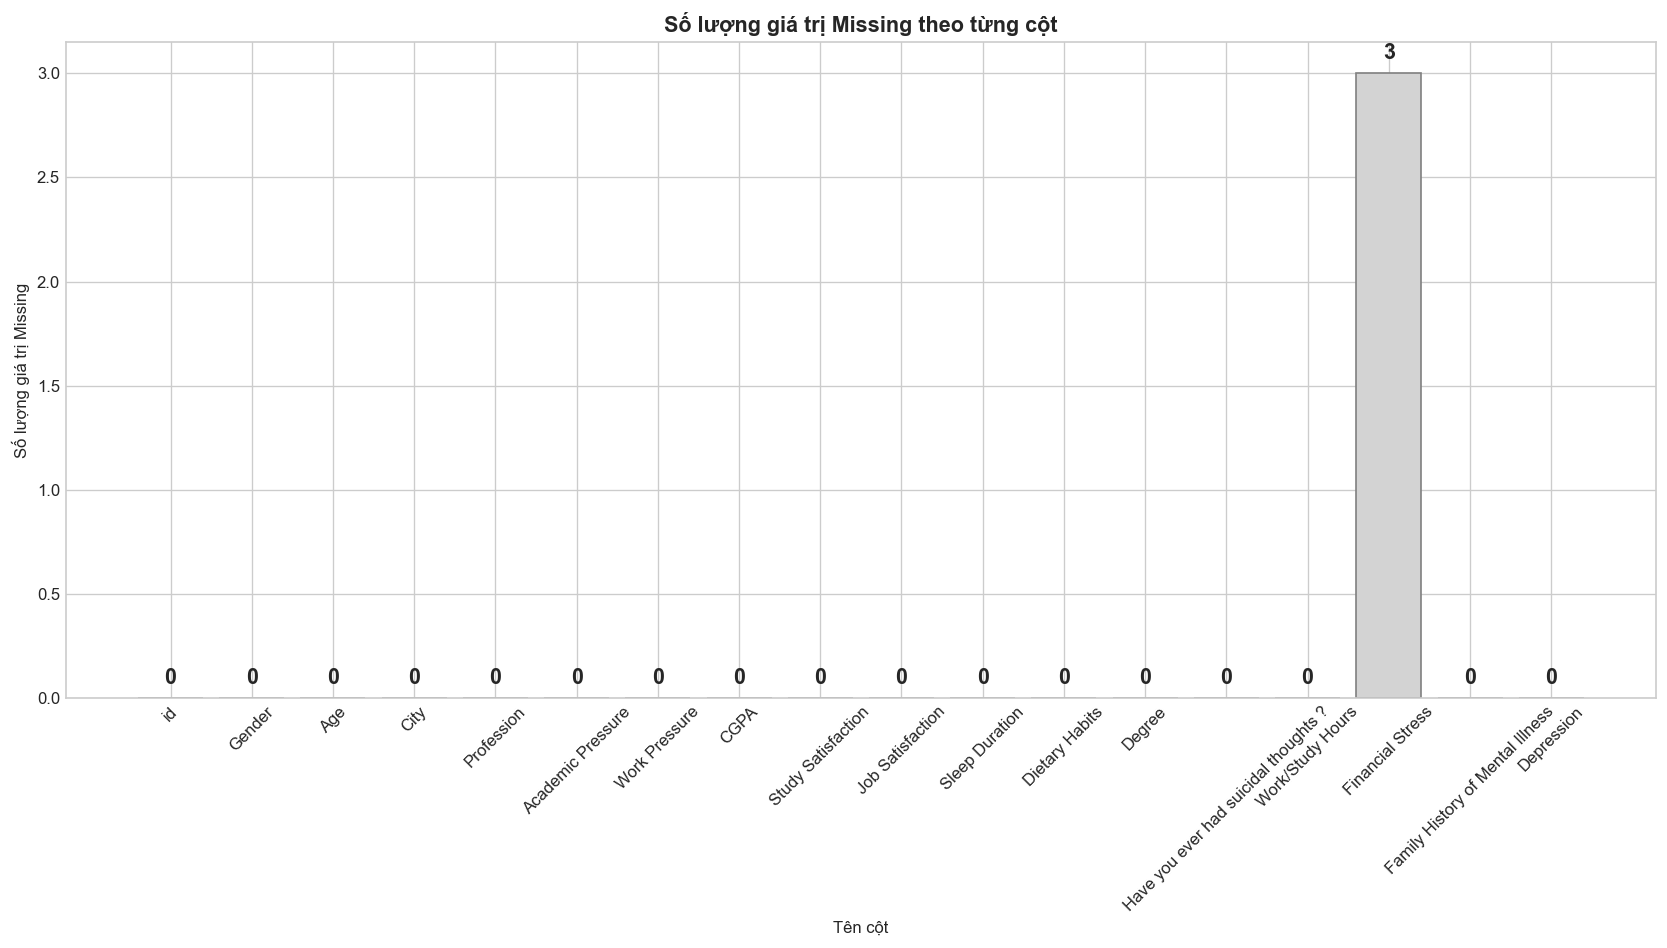

In [81]:
plt.figure(figsize=(14, 8))
bars = plt.bar(missing.index, missing.values,
    color='lightgray', edgecolor='gray')
plt.title('Số lượng giá trị Missing theo từng cột', fontsize=13, fontweight='bold')
plt.xlabel('Tên cột')
plt.ylabel('Số lượng giá trị Missing')
plt.xticks(rotation=45, fontsize=10)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Xử lý missing values và mã hóa dữ liệu

In [82]:
df_clean = df.copy()

# ── 1. Xử lý missing values ───────────────────────────────────────────────────
n_missing = df_clean.isnull().sum().sum()
if n_missing > 0:
    # Số: điền median; Categorical: điền mode
    num_feats = df_clean.select_dtypes(include=np.number).columns.tolist()
    cat_feats  = df_clean.select_dtypes(include='object').columns.tolist()
    for c in num_feats:
        df_clean[c].fillna(df_clean[c].median(), inplace=True)
    for c in cat_feats:
        df_clean[c].fillna(df_clean[c].mode()[0], inplace=True)
    print(f"✅ Đã xử lý {n_missing} missing values")
else:
    print("✅ Không có missing values")

# ── 2. Mã hóa Sleep Duration (ordinal — có thứ tự) ───────────────────────────
sleep_map = {
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    '7-8 hours': 3,
    'More than 8 hours': 4
}
df_clean['Sleep Duration Enc'] = df_clean['Sleep Duration'].map(sleep_map).fillna(2)
print(f"✅ Mã hóa Sleep Duration (ordinal): {sleep_map}")

# ── 3. Mã hóa Dietary Habits (ordinal) ───────────────────────────────────────
diet_map = {'Unhealthy': 1, 'Moderate': 2, 'Healthy': 3}
df_clean['Dietary Habits Enc'] = df_clean['Dietary Habits'].map(diet_map).fillna(2)
print(f"✅ Mã hóa Dietary Habits (ordinal):   {diet_map}")

# ── 4. Mã hóa binary ─────────────────────────────────────────────────────────
binary_cols = {
    'Gender':                               {'Male': 0, 'Female': 1},
    'Have you ever had suicidal thoughts ?':{'No': 0, 'Yes': 1},
    'Family History of Mental Illness':     {'No': 0, 'Yes': 1},
}
for col, mapping in binary_cols.items():
    df_clean[col + ' Enc'] = df_clean[col].map(mapping)
    print(f"✅ Mã hóa {col}: {mapping}")

# ── 5. Mã hóa nominal còn lại (City, Degree, Profession) ─────────────────────
nominal_cols = ['City', 'Degree', 'Profession']
le_dict = {}
for c in nominal_cols:
    le = LabelEncoder()
    df_clean[c + ' Enc'] = le.fit_transform(df_clean[c].astype(str))
    le_dict[c] = le
    print(f"✅ LabelEncoder {c}: {len(le.classes_)} nhãn")

# ── 6. Định nghĩa feature set ────────────────────────────────────────────────
FEATURES = [
    # Biến số gốc
    'Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
    'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress',
    # Biến đã mã hóa
    'Sleep Duration Enc', 'Dietary Habits Enc',
    'Gender Enc',
    'Have you ever had suicidal thoughts ? Enc',
    'Family History of Mental Illness Enc',
    'City Enc', 'Degree Enc', 'Profession Enc'
]

X = df_clean[FEATURES]
# X = X.fillna(X.mean())
X = X.apply(lambda col: col.fillna(col.mode()[0]) if not col.mode().empty else col)
y = df_clean[TARGET_COL]
print(f"✅ Feature set: {len(FEATURES)} features")
print(f"   Shape X: {X.shape} | Shape y: {y.shape}")
print(f"   Target: 0={( y==0).sum():,}  1={(y==1).sum():,}")

✅ Đã xử lý 3 missing values
✅ Mã hóa Sleep Duration (ordinal): {'Less than 5 hours': 1, '5-6 hours': 2, '7-8 hours': 3, 'More than 8 hours': 4}
✅ Mã hóa Dietary Habits (ordinal):   {'Unhealthy': 1, 'Moderate': 2, 'Healthy': 3}
✅ Mã hóa Gender: {'Male': 0, 'Female': 1}
✅ Mã hóa Have you ever had suicidal thoughts ?: {'No': 0, 'Yes': 1}
✅ Mã hóa Family History of Mental Illness: {'No': 0, 'Yes': 1}
✅ LabelEncoder City: 52 nhãn
✅ LabelEncoder Degree: 28 nhãn
✅ LabelEncoder Profession: 14 nhãn
✅ Feature set: 16 features
   Shape X: (27901, 16) | Shape y: (27901,)
   Target: 0=11,565  1=16,336


## 4. Phân tích khám phá dữ liệu
### 4.1 Phân bố biến mục tiêu `Depression`

Phân bố Depression:
  0 — Không trầm cảm: 11,565 (41.5%)
  1 — Có trầm cảm:    16,336 (58.5%)


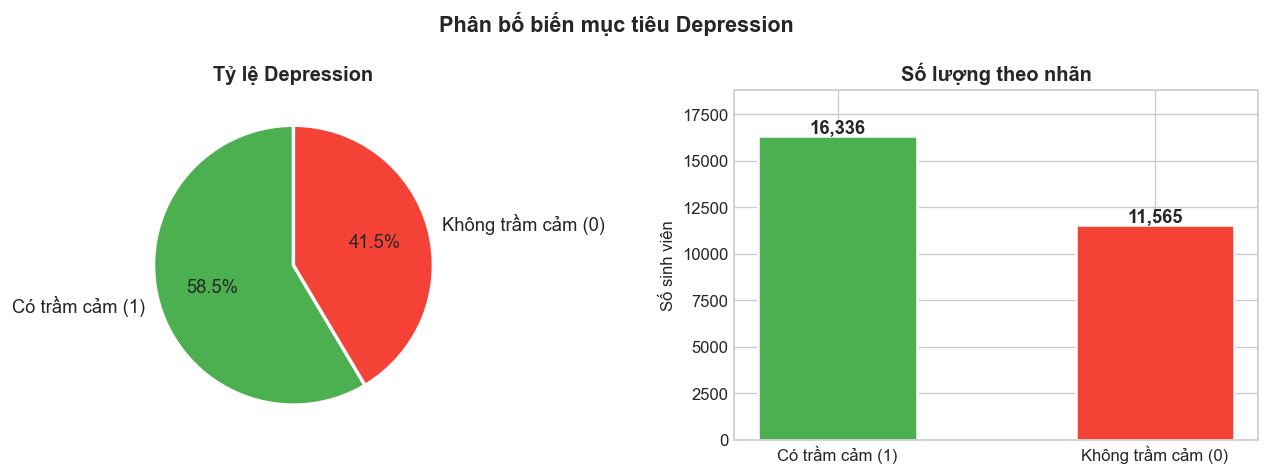

In [83]:
dep_counts = df[TARGET_COL].value_counts()
dep_pct    = df[TARGET_COL].value_counts(normalize=True) * 100

print("Phân bố Depression:")
print(f"  0 — Không trầm cảm: {dep_counts[0]:,} ({dep_pct[0]:.1f}%)")
print(f"  1 — Có trầm cảm:    {dep_counts[1]:,} ({dep_pct[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie
axes[0].pie(dep_counts, labels=['Có trầm cảm (1)', 'Không trầm cảm (0)'],
            colors=[COLORS['green'], COLORS['red']], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11})
axes[0].set_title('Tỷ lệ Depression', fontweight='bold')

# Bar
bars = axes[1].bar(['Có trầm cảm (1)', 'Không trầm cảm (0)'],
                   dep_counts.values,
                   color=[COLORS['green'], COLORS['red']],
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, dep_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Số lượng theo nhãn', fontweight='bold')
axes[1].set_ylabel('Số sinh viên')
axes[1].set_ylim(0, max(dep_counts.values) * 1.15)

plt.suptitle('Phân bố biến mục tiêu Depression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Phân bố của các thuộc tính

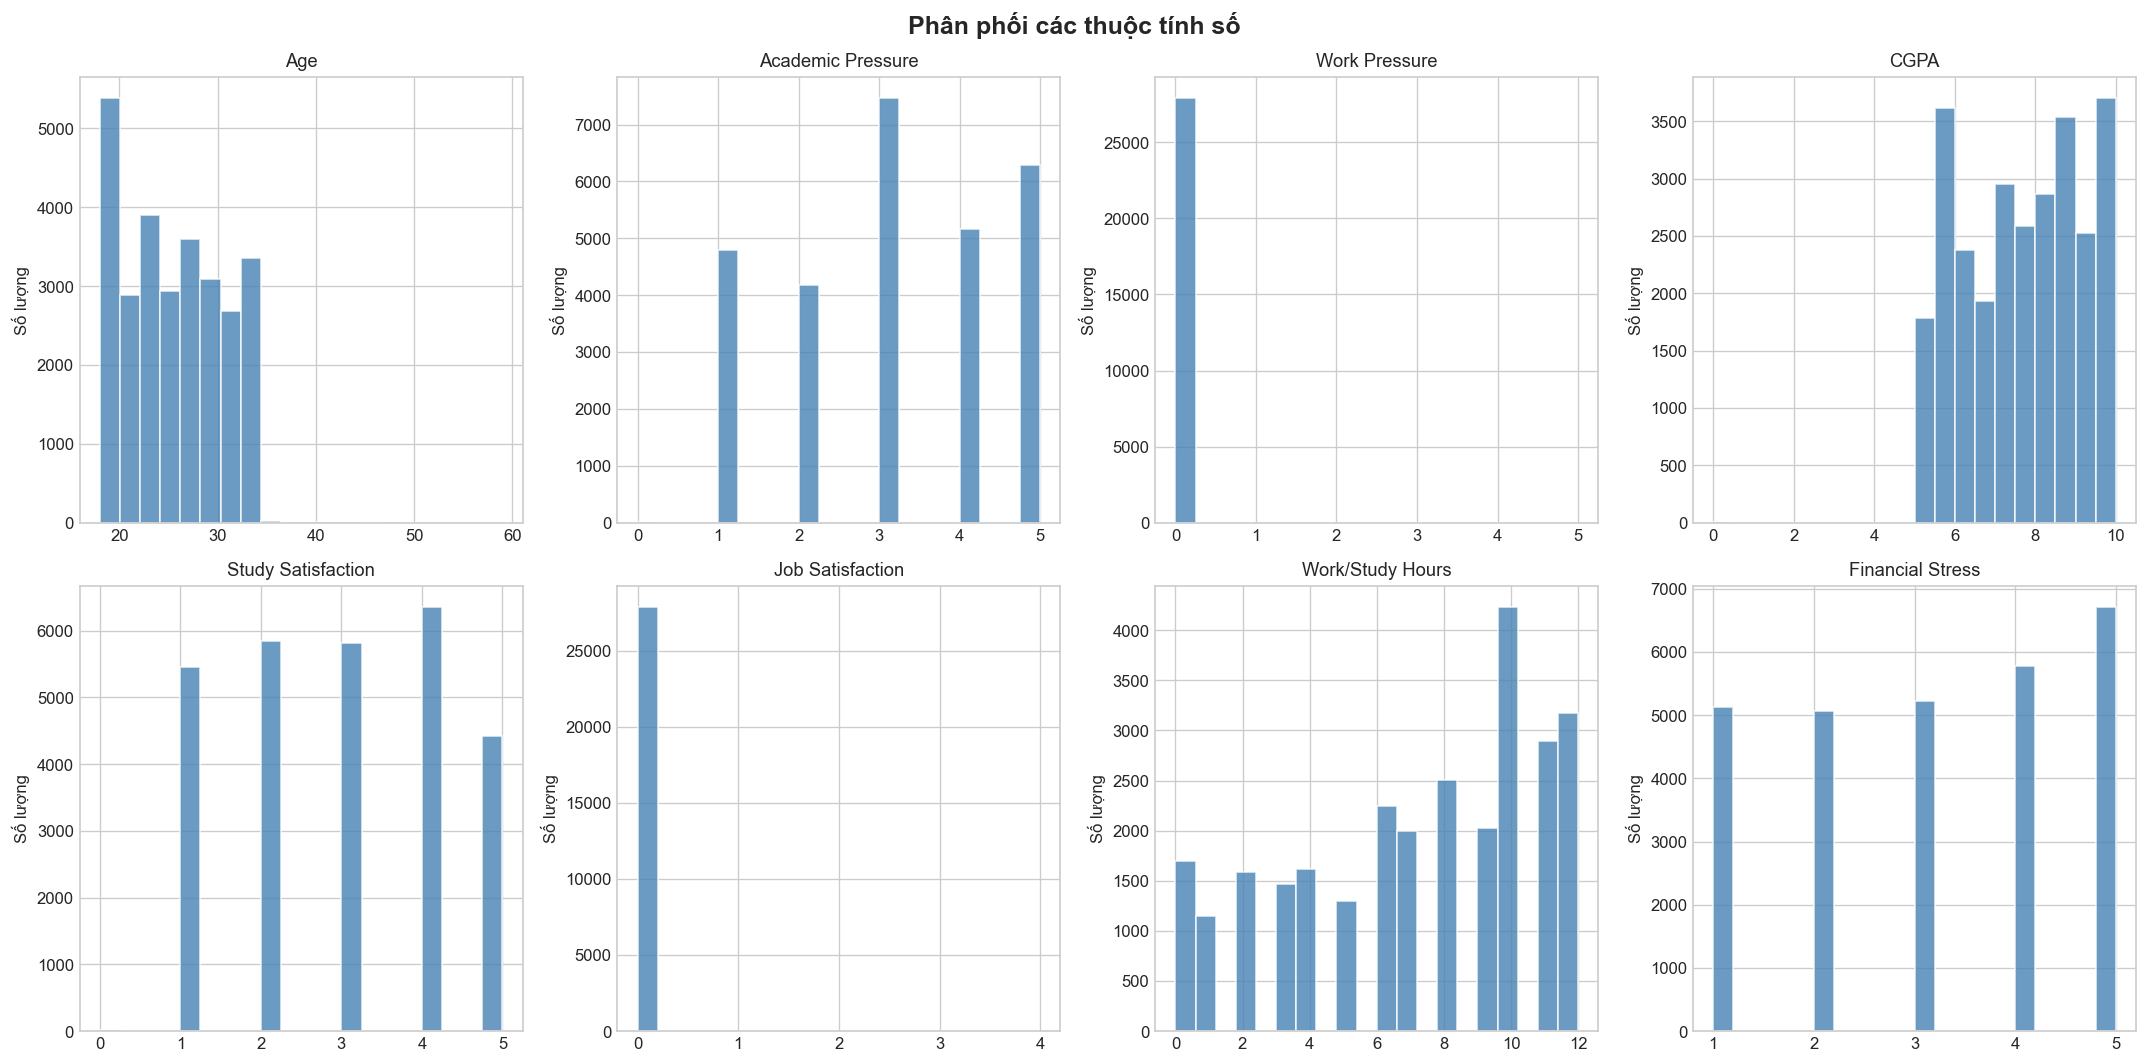

In [84]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Phân phối các thuộc tính số', fontsize=15, fontweight='bold')
num_cols = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
            'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df_clean[col].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Số lượng')
    mean_val = df_clean[col].mean()
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

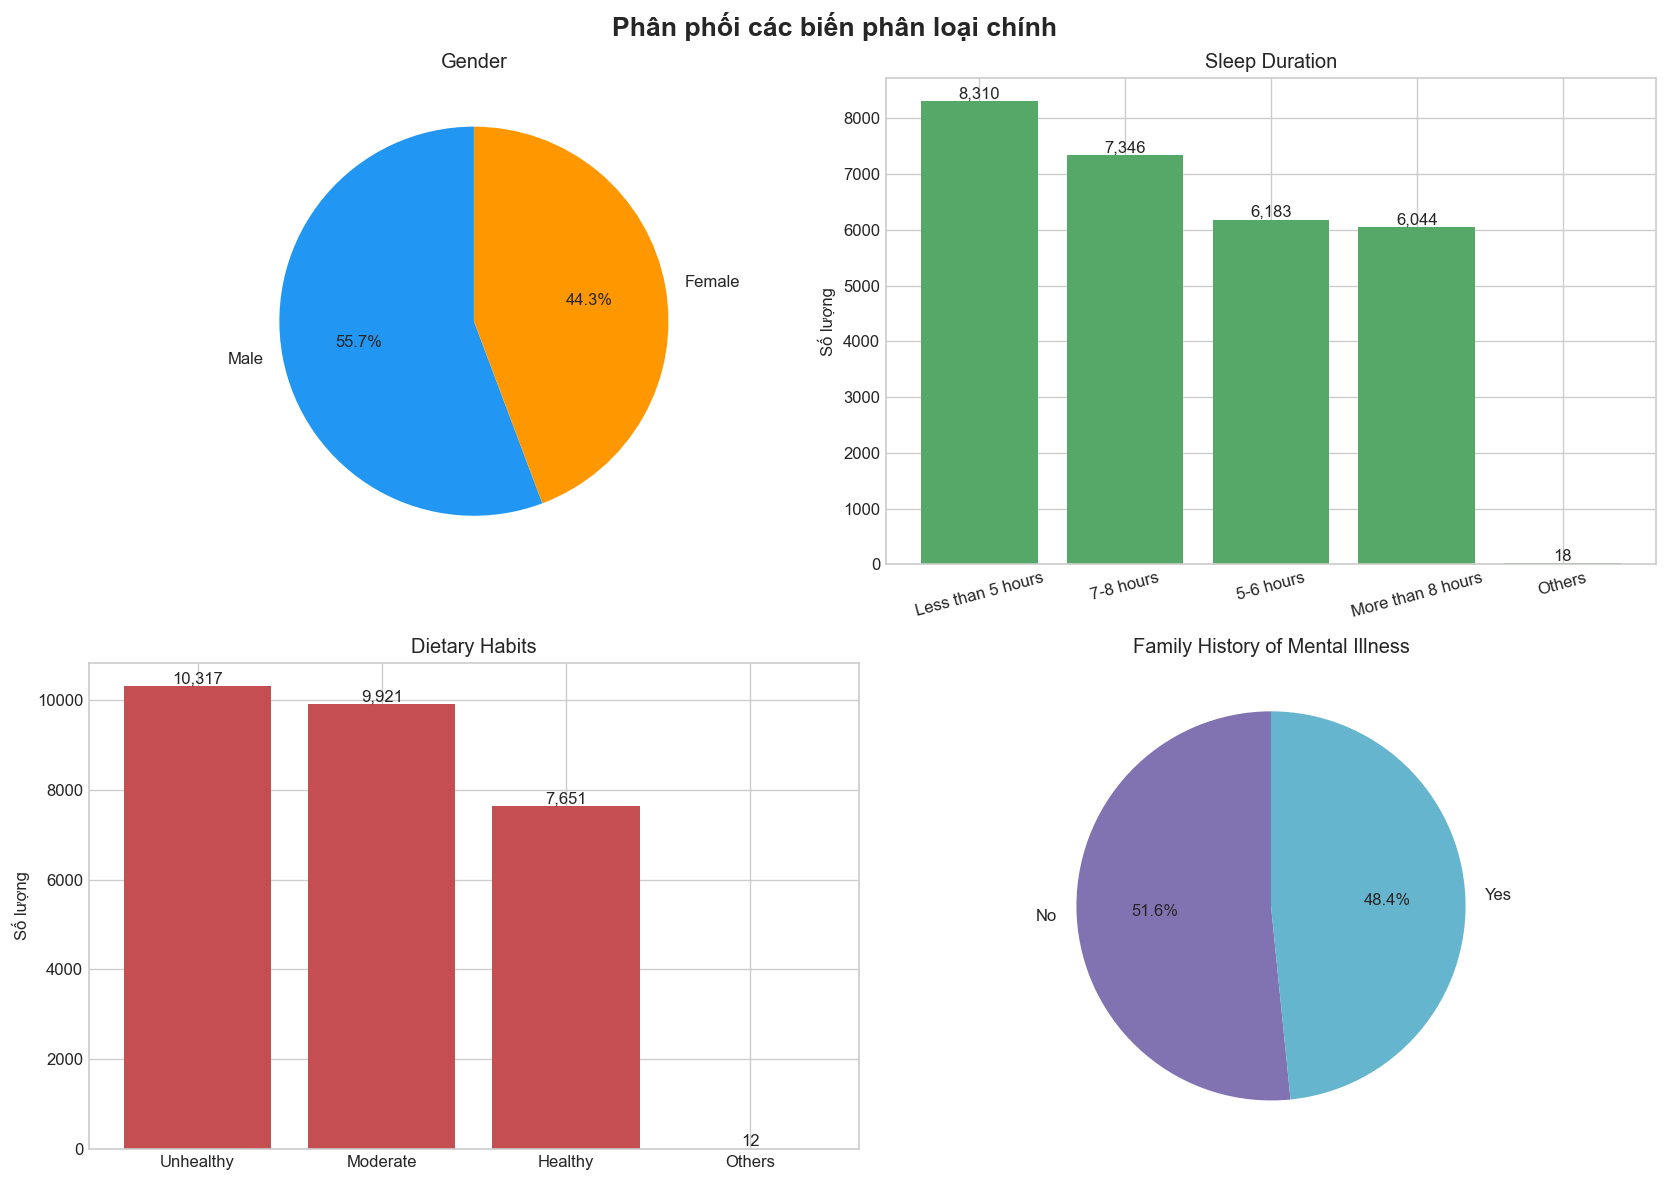

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Phân phối các biến phân loại chính', fontsize=16, fontweight='bold')
gender_counts = df_clean['Gender'].value_counts()
axes[0, 0].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[COLORS['blue'], COLORS['orange']])
axes[0, 0].set_title('Gender')
# ============================================================ 
sleep_counts = df_clean['Sleep Duration'].value_counts()
axes[0, 1].bar(
    sleep_counts.index,
    sleep_counts.values,
    color='#55A868')
axes[0, 1].set_title('Sleep Duration')
axes[0, 1].set_ylabel('Số lượng')
axes[0, 1].tick_params(axis='x', rotation=15)
for i, v in enumerate(sleep_counts.values):
    axes[0, 1].text(i, v + 50, f'{v:,}', ha='center')
# ============================================================ 
diet_counts = df_clean['Dietary Habits'].value_counts()
axes[1, 0].bar(
    diet_counts.index,
    diet_counts.values,
    color='#C44E52')
axes[1, 0].set_title('Dietary Habits')
axes[1, 0].set_ylabel('Số lượng')
for i, v in enumerate(diet_counts.values):
    axes[1, 0].text(i, v + 50, f'{v:,}', ha='center')
# ============================================================ 
family_counts = df_clean['Family History of Mental Illness'].value_counts()
axes[1, 1].pie(
    family_counts.values,
    labels=family_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#8172B2', '#64B5CD'])
axes[1, 1].set_title('Family History of Mental Illness')
plt.tight_layout()
plt.show()

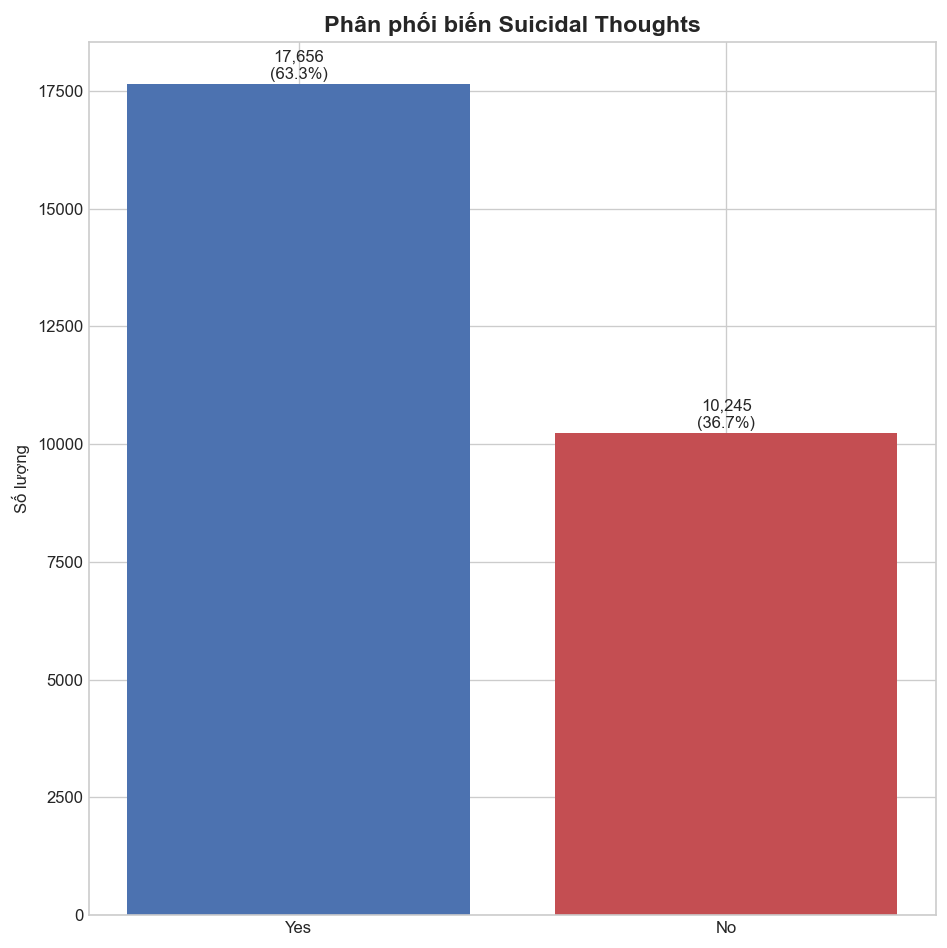

In [86]:
plt.figure(figsize=(8, 8))
suicidal_counts = df_clean['Have you ever had suicidal thoughts ?'].value_counts()
bars = plt.bar(
    suicidal_counts.index,
    suicidal_counts.values,
    color=['#4C72B0', '#C44E52'])
plt.title('Phân phối biến Suicidal Thoughts', fontsize=14, fontweight='bold')
plt.ylabel('Số lượng')
for i, v in enumerate(suicidal_counts.values):
    plt.text(i, v + 100, f'{v:,}\n({v/len(df_clean)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

### 4.3 Tỷ lệ trầm cảm theo từng mức độ áp lực học tập & tài chính

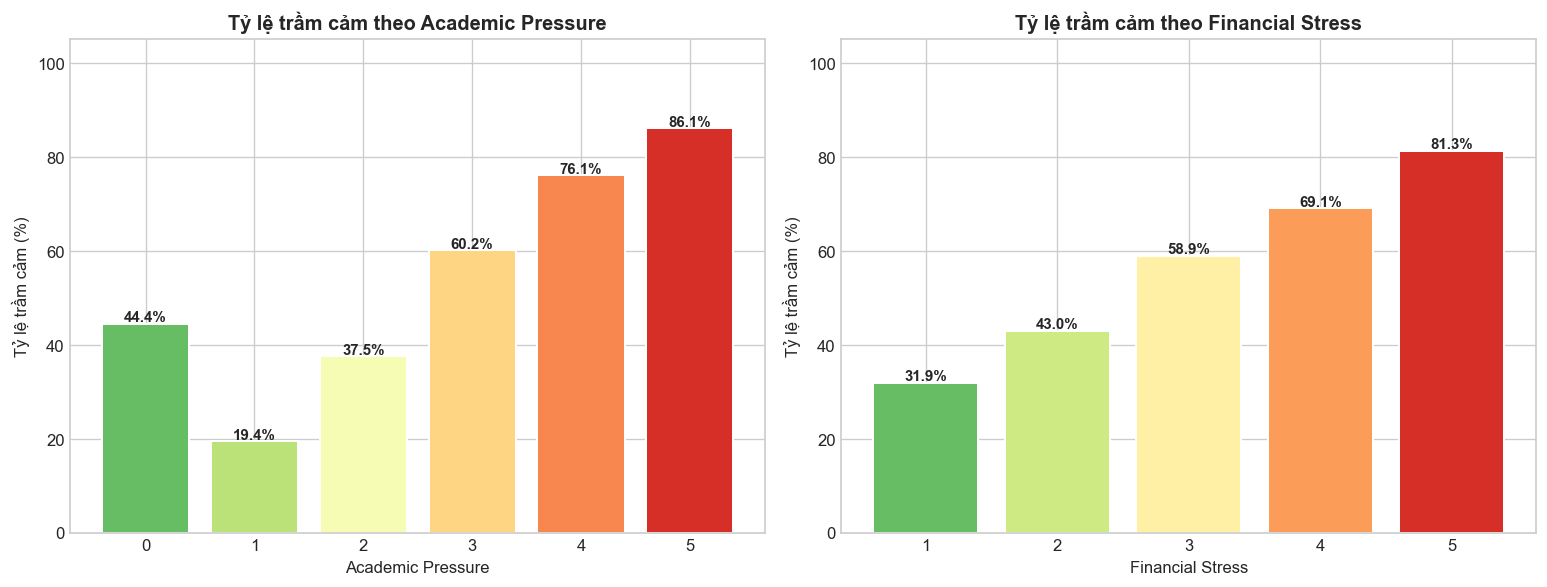

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat, title in [
    (axes[0], 'Academic Pressure', 'Áp lực học tập'),
    (axes[1], 'Financial Stress',  'Stress tài chính')
]:
    dep_rate = df_clean.groupby(feat)[TARGET_COL].mean() * 100
    bars = ax.bar(dep_rate.index, dep_rate.values,
                  color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(dep_rate))),
                  edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, dep_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Tỷ lệ trầm cảm theo {feat}', fontweight='bold')
    ax.set_xlabel(feat); ax.set_ylabel('Tỷ lệ trầm cảm (%)')
    ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

### 4.4 Tỷ lệ trầm cảm theo giờ ngủ & chế độ ăn

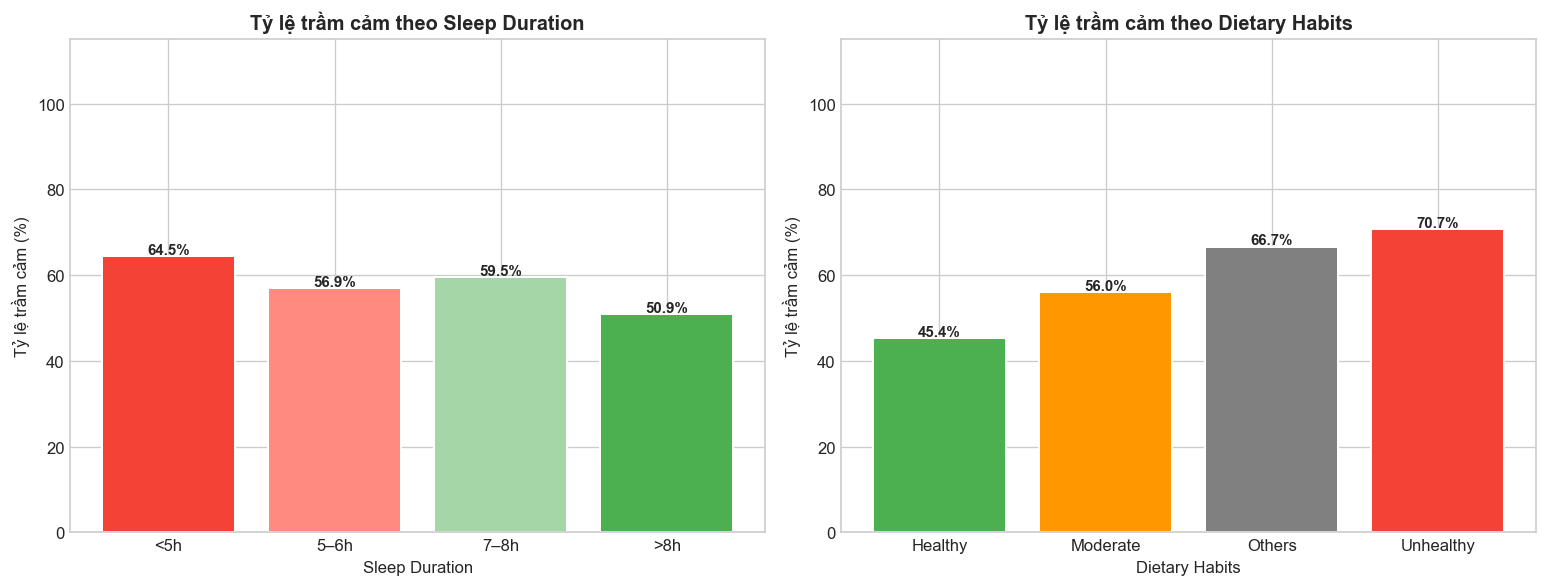

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Giờ ngủ
ax = axes[0]
sleep_dep = df_clean.groupby('Sleep Duration')[TARGET_COL].mean() * 100
sleep_dep = sleep_dep.reindex(['Less than 5 hours','5-6 hours','7-8 hours','More than 8 hours'])
bars = ax.bar(range(len(sleep_dep)), sleep_dep.values,
              color=[COLORS['red'], '#FF8A80', '#A5D6A7', COLORS['green']],
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, sleep_dep.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(sleep_dep)))
ax.set_xticklabels(['<5h', '5–6h', '7–8h', '>8h'])
ax.set_title('Tỷ lệ trầm cảm theo Sleep Duration', fontweight='bold')
ax.set_xlabel('Sleep Duration')
ax.set_ylabel('Tỷ lệ trầm cảm (%)')
ax.set_ylim(0, 115)

# Chế độ ăn
ax = axes[1]
diet_dep = df_clean.groupby('Dietary Habits')[TARGET_COL].mean() * 100
colors_diet = {'Unhealthy': COLORS['red'], 'Moderate': COLORS['orange'], 'Healthy': COLORS['green']}
bars = ax.bar(diet_dep.index, diet_dep.values,
              color=[colors_diet.get(k, 'gray') for k in diet_dep.index],
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, diet_dep.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Tỷ lệ trầm cảm theo Dietary Habits', fontweight='bold')
ax.set_xlabel('Dietary Habits')
ax.set_ylabel('Tỷ lệ trầm cảm (%)')
ax.set_ylim(0, 115)

plt.tight_layout()
plt.show()

### 4.5 Phân bố suy nghĩ tự tử & tiền sử gia đình

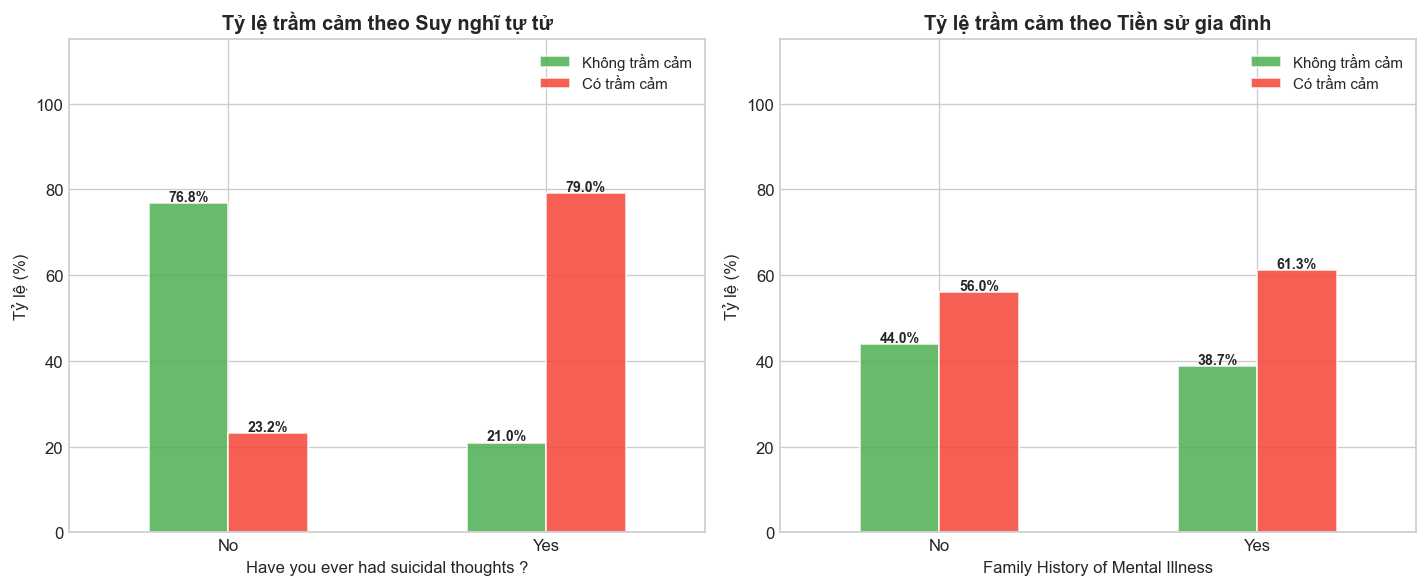

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in [
    (axes[0], 'Have you ever had suicidal thoughts ?', 'Suy nghĩ tự tử'),
    (axes[1], 'Family History of Mental Illness',      'Tiền sử gia đình'),
]:
    ct = pd.crosstab(df_clean[col], df_clean[TARGET_COL], normalize='index') * 100
    ct.columns = ['Không trầm cảm', 'Có trầm cảm']
    ct.plot(kind='bar', ax=ax, color=[COLORS['green'], COLORS['red']],
            edgecolor='white', alpha=0.85)
    ax.set_title(f'Tỷ lệ trầm cảm theo {title}', fontweight='bold')
    ax.set_ylabel('Tỷ lệ (%)'); ax.set_ylim(0, 115)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=9)
    for bar in ax.patches:
        h = bar.get_height()
        if h > 2:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.5,
                    f'{h:.1f}%', ha='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.6 Mối quan hệ giữa áp lực học tập và căng thẳng tài chính

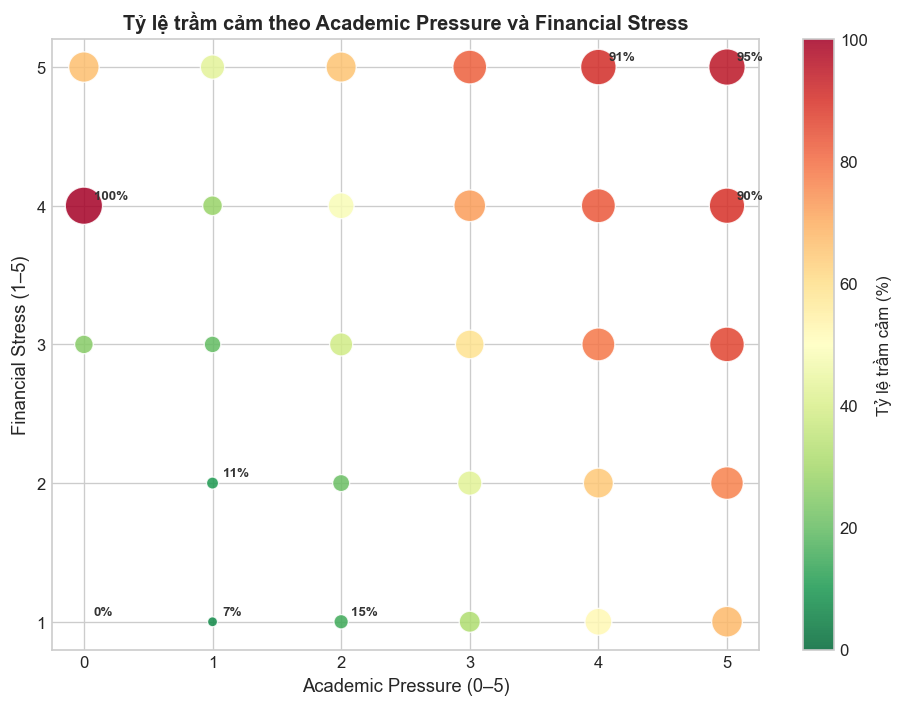

In [90]:
sleep_order = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']
diet_order  = ['Unhealthy', 'Moderate', 'Healthy']
plt.figure(figsize=(8, 6))
pivot = (
    df_clean
    .groupby(['Academic Pressure', 'Financial Stress'])['Depression']
    .mean() * 100
)
pivot = pivot.reset_index()
pivot.columns = ['AP', 'FS', 'dep_rate']
sc = plt.scatter(
    pivot['AP'],
    pivot['FS'],
    s=pivot['dep_rate'] * 5,
    c=pivot['dep_rate'],
    cmap='RdYlGn_r',
    alpha=0.85,
    edgecolors='white',
    linewidths=0.8,
    vmin=0,
    vmax=100
)
plt.colorbar(sc, label='Tỷ lệ trầm cảm (%)')
for _, row in pivot.iterrows():
    if row['dep_rate'] > 90 or row['dep_rate'] < 15:
        plt.annotate(
            f"{row['dep_rate']:.0f}%",
            (row['AP'], row['FS']),
            textcoords='offset points',
            xytext=(6, 4),
            fontsize=8,
            color='#333',
            fontweight='bold')

plt.xlabel('Academic Pressure (0–5)', fontsize=11)
plt.ylabel('Financial Stress (1–5)', fontsize=11)
plt.title('Tỷ lệ trầm cảm theo Academic Pressure và Financial Stress',
    fontsize=12, fontweight='bold'
)
plt.xticks([0, 1, 2, 3, 4, 5])
plt.yticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

### 4.7 Mối quan hệ giữa giờ ngủ và chế độ ăn

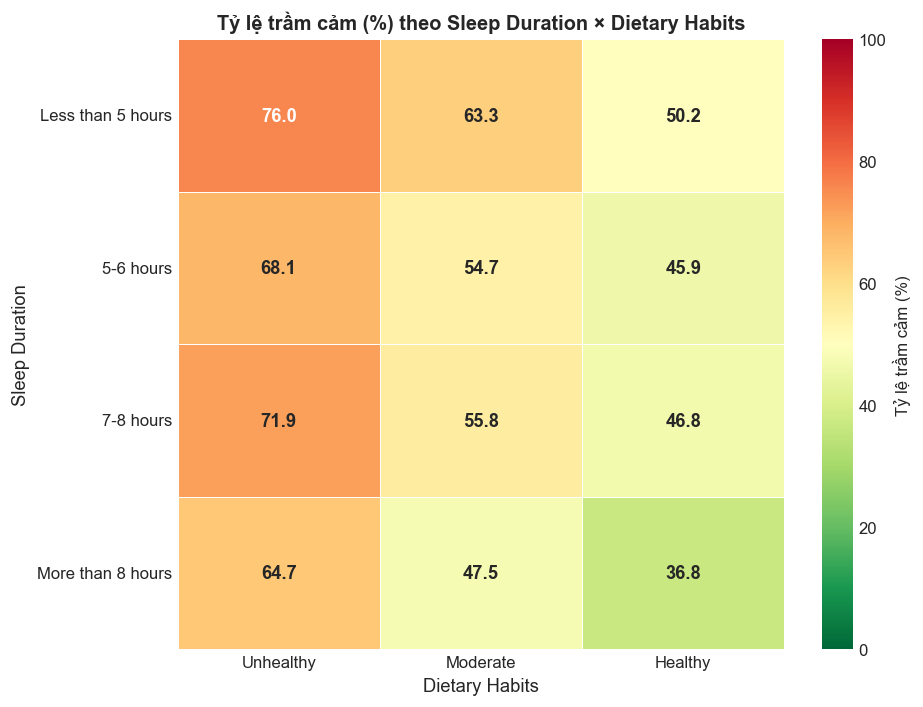

In [91]:
plt.figure(figsize=(8, 6))
pivot_lifestyle = (
    df_clean
    .groupby(['Sleep Duration', 'Dietary Habits'])['Depression']
    .mean() * 100)
pivot_table = pivot_lifestyle.unstack(level='Dietary Habits')
pivot_table = pivot_table.reindex(index=sleep_order, columns=diet_order)
sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    vmin=0,
    vmax=100,
    center=50,
    linewidths=0.5,
    annot_kws={'size': 11, 'weight': 'bold'},
    cbar_kws={'label': 'Tỷ lệ trầm cảm (%)'}
)
plt.title('Tỷ lệ trầm cảm (%) theo Sleep Duration × Dietary Habits',
    fontsize=12, fontweight='bold')
plt.xlabel('Dietary Habits', fontsize=11)
plt.ylabel('Sleep Duration', fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

### 4.8 Heatmap tương quan toàn bộ features

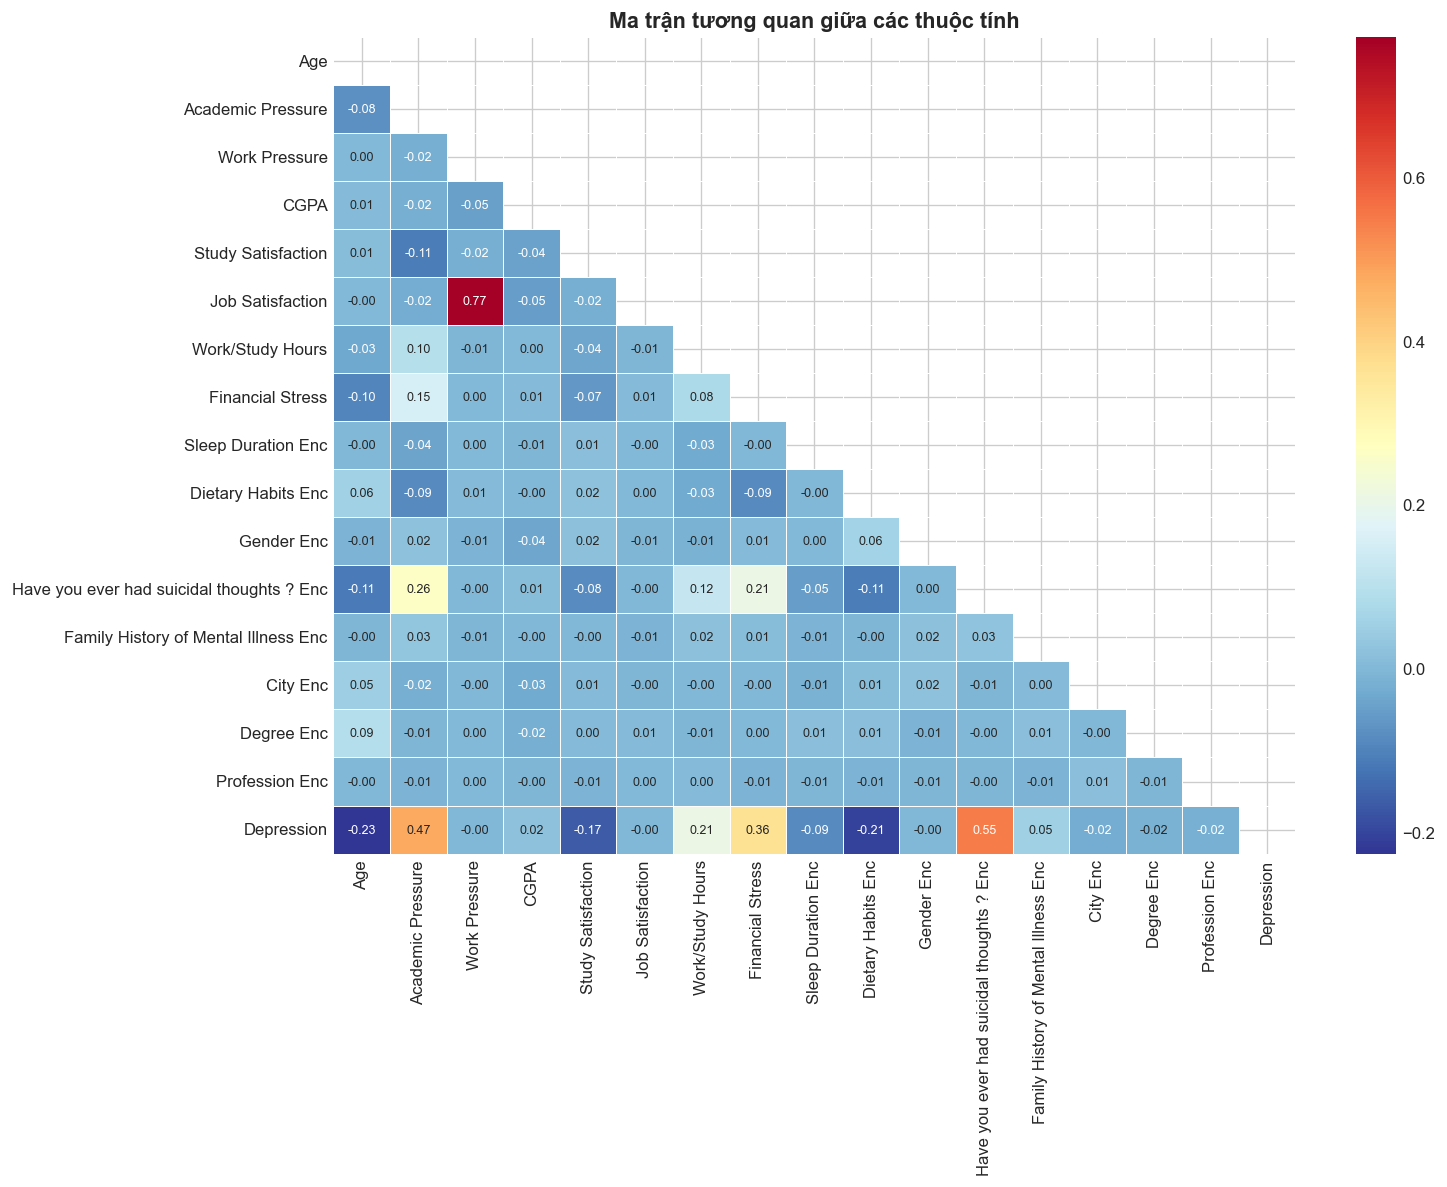

In [92]:
fig, ax = plt.subplots(figsize=(13, 10))
corr_mat = df_clean[FEATURES + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            ax=ax, annot_kws={'size': 7.5}, linewidths=0.4)
ax.set_title('Ma trận tương quan giữa các thuộc tính', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()